In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from optbinning import BinningProcess

# Load data
data = fetch_openml('credit-g', version=1, as_frame=True)
df = data.frame

print("Libraries imported and data loaded successfully!")

Libraries imported and data loaded successfully!


In [2]:
# Encode target variable
df['target'] = df['class'].map({'good': 0, 'bad': 1})

# Convert low unique value variables to categorical
cols_to_categorical = ['installment_commitment', 'residence_since', 
                       'existing_credits', 'num_dependents']
for col in cols_to_categorical:
    df[col] = df[col].astype(str)

# Log transform credit_amount
df['log_credit_amount'] = np.log(df['credit_amount'])

# Define features and target
X = df.drop(columns=['class', 'target', 'credit_amount'])
y = df['target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Convert all category dtype columns to string
for col in X_train.columns:
    if X_train[col].dtype.name == 'category':
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

# Define categorical variables
categorical_variables = [col for col in X_train.columns 
                         if X_train[col].dtype == 'object' 
                         or X_train[col].dtype.name == 'str']

# Fit and transform using WoE
binning_process = BinningProcess(
    variable_names=list(X_train.columns),
    categorical_variables=categorical_variables,
    max_n_bins=5)

binning_process.fit(X_train, y_train)

X_train_woe = binning_process.transform(X_train)
X_test_woe = binning_process.transform(X_test)

# Drop low IV variables
cols_to_drop = ['other_parties', 'residence_since', 'num_dependents', 'foreign_worker']
X_train_woe = X_train_woe.drop(columns=cols_to_drop)
X_test_woe = X_test_woe.drop(columns=cols_to_drop)

print("Preprocessing complete!")
print(f"Training set shape: {X_train_woe.shape}")
print(f"Test set shape: {X_test_woe.shape}")

Preprocessing complete!
Training set shape: (800, 16)
Test set shape: (200, 16)


In [4]:
from sklearn.linear_model import LogisticRegression

# Model 1 - cost matrix embedded in class_weight
model_1 = LogisticRegression(
    class_weight={0: 1, 1: 5},
    random_state=42,
    max_iter=1000
)
model_1.fit(X_train_woe, y_train)

# Model 2 - standard model with cost-based threshold adjustment
# no class_weight here - cost is applied through threshold instead
model_2 = LogisticRegression(
    random_state=42,
    max_iter=1000
)
model_2.fit(X_train_woe, y_train)

print("Both models trained successfully!")

Both models trained successfully!


In [5]:
def cost_weighted_misclassification(y_true, y_pred):
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    total_cost = (5 * fn + 1 * fp) / len(y_true)
    return total_cost

# Model 1 predictions - using default 0.5 threshold
y_pred_1 = model_1.predict(X_test_woe)

# Model 2 predictions - using cost-based threshold of 0.167
y_prob_2 = model_2.predict_proba(X_test_woe)[:, 1]
threshold = 1 / (1 + 5)
y_pred_2 = (y_prob_2 >= threshold).astype(int)

# Evaluate both
cost_1 = cost_weighted_misclassification(y_test, y_pred_1)
cost_2 = cost_weighted_misclassification(y_test, y_pred_2)

print(f"Model 1 cost-weighted misclassification rate: {cost_1:.4f}")
print(f"Model 2 cost-weighted misclassification rate: {cost_2:.4f}")
print(f"\nLower is better!")

Model 1 cost-weighted misclassification rate: 0.5850
Model 2 cost-weighted misclassification rate: 0.5950

Lower is better!


In [6]:
# Naive model - predict everyone as bad
y_pred_naive = np.ones(len(y_test))
cost_naive = cost_weighted_misclassification(y_test, y_pred_naive)
print(f"Naive model cost: {cost_naive:.4f}")

Naive model cost: 0.7000


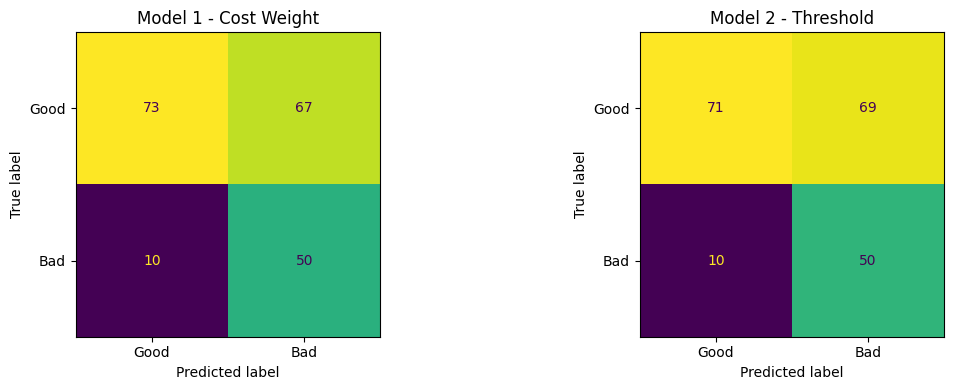

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (model_name, y_pred) in enumerate([
    ('Model 1 - Cost Weight', y_pred_1),
    ('Model 2 - Threshold', y_pred_2)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Bad'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(model_name)

plt.tight_layout()
plt.show()

In [8]:
from optbinning import Scorecard

scorecard = Scorecard(
    binning_process=binning_process,
    estimator=model_1,
    scaling_method="pdo_odds",
    scaling_method_params={
        "pdo": 20,
        "odds": 1,
        "scorecard_points": 600
    }
)

scorecard.fit(X_train, y_train)

print("Scorecard built successfully!")

Scorecard built successfully!


In [9]:
scorecard.table(style="summary")

,Variable,Bin,Points
0,checking_status,[no checking],55.677448
1,checking_status,[>=200],34.209440
2,checking_status,[0<=X<200],19.328314
3,checking_status,[<0],11.033148
4,checking_status,Special,28.936290
...,...,...,...
2,log_credit_amount,"[8.15, 8.27)",77.432145
3,log_credit_amount,"[8.27, 8.97)",20.271449
4,log_credit_amount,"[8.97, inf)",-3.365188
5,log_credit_amount,Special,28.936290


In [10]:
scores = scorecard.score(X_test)

results = pd.DataFrame({
    'score': scores,
    'actual': y_test.values.astype(int)
})

print(f"Score range: {results['score'].min():.0f} to {results['score'].max():.0f}")
print(f"Average score: {results['score'].mean():.0f}")
print(f"\nAverage score for good customers: {results[results['actual']==0]['score'].mean():.0f}")
print(f"Average score for bad customers: {results[results['actual']==1]['score'].mean():.0f}")

Score range: 474 to 729
Average score: 589

Average score for good customers: 605
Average score for bad customers: 552


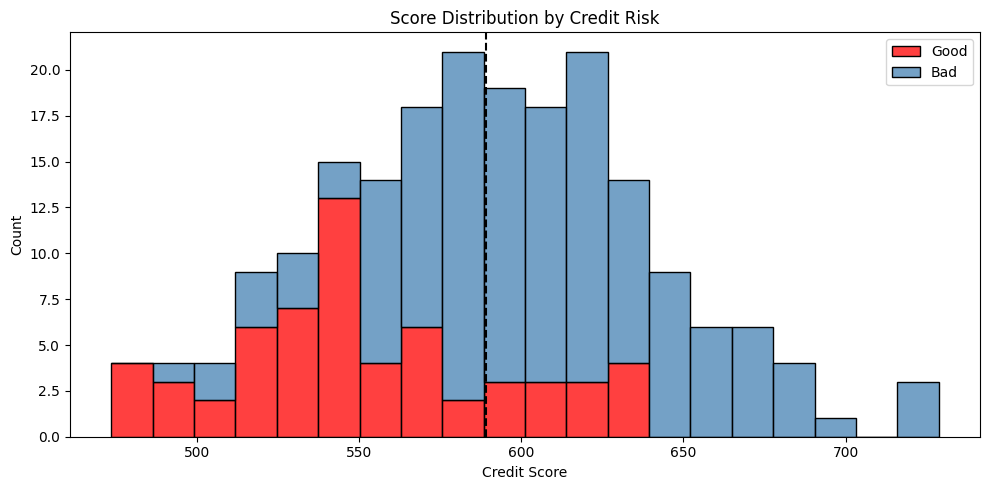

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(data=results, x='score', hue='actual', bins=20, 
             palette={0: 'steelblue', 1: 'red'}, 
             multiple='stack')
plt.title('Score Distribution by Credit Risk')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.legend(labels=['Good', 'Bad'])
plt.axvline(x=results['score'].mean(), color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [12]:
scenarios = {
    'Baseline': 0,
    'Adverse': -20,
    'Severely Adverse': -40
}

cutoff = 600

print(f"{'Scenario':<20} {'Bad Rate':>10}")
print("-" * 32)

for scenario, shift in scenarios.items():
    stressed_scores = results['score'] + shift
    predicted_bad = (stressed_scores < cutoff).astype(int)
    bad_rate = (results['actual'] == 1).mean() * 100
    approval_rate = (stressed_scores >= cutoff).mean() * 100
    rejected_bad_rate = results.loc[stressed_scores < cutoff, 'actual'].mean() * 100
    
    print(f"{scenario:<20} {bad_rate:>8.1f}%")
    print(f"{'Approval rate':<20} {approval_rate:>8.1f}%")
    print(f"{'Bad rate in rejected':<20} {rejected_bad_rate:>8.1f}%")
    print()

Scenario               Bad Rate
--------------------------------
Baseline                 30.0%
Approval rate            41.5%
Bad rate in rejected     42.7%

Adverse                  30.0%
Approval rate            26.5%
Bad rate in rejected     37.4%

Severely Adverse         30.0%
Approval rate            14.5%
Bad rate in rejected     35.1%

